# Basic classification + noise — L1 lab

**Multi-class** text classification on one dataset (Bitext customer-support categories), two
classifiers (TF-IDF + LogReg and an LLM few-shot model), four demos that all land on the same
L1 punchline: **a single accuracy number is one draw**.

Each ticket is routed to exactly one of five categories, so accuracy is cleanly binary per
example. (Multi-label classification — many tags per item — and non-classification tasks come
in later lessons; here we keep it to the clean multi-class case.)

Source of uncertainty in focus: **sampling noise**.

## Setup

In [1]:
import os, json
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv, find_dotenv
# find_dotenv walks up from the lab folder, so a .env at the repo root is found too.
load_dotenv(find_dotenv(usecwd=True))

from lab import (
    load_bitext, label_set_of, label_of,
    TfidfLogRegClassifier, LlmFewShotClassifier, MajorityBaseline,
    evaluate, prepare, evaluate_resample, skewed_indices,
)

pd.set_option('display.max_colwidth', 80)

## Dataset

Bitext customer-support utterances, loaded from `../../datasets/` (first run pulls from
HuggingFace and caches a small subset). We restrict to five coarse **categories** — each
utterance carries exactly one. Multi-class: one property, the category.

In [2]:
bitext = load_bitext(n=2000)
classes = sorted(label_set_of(bitext))
print(f'bitext: {len(bitext)} rows, {len(classes)} classes -> {classes}\n')
print('class distribution:')
print(pd.Series([label_of(l) for l in bitext['labels']]).value_counts())
print()
print(bitext.assign(category=[label_of(l) for l in bitext['labels']])[['text','category']].head(5))

bitext: 2000 rows, 5 classes -> ['ACCOUNT', 'DELIVERY', 'ORDER', 'PAYMENT', 'REFUND']

class distribution:
ACCOUNT     695
ORDER       482
REFUND      355
DELIVERY    238
PAYMENT     230
Name: count, dtype: int64

                                                 text category
0  what do i need to do to change to the gold account  ACCOUNT
1             how canI change order {{Order Number}}?    ORDER
2      can  uhelp me canceling order {{Order Number}}    ORDER
3   I do not know how I could ask for goddamn refunds   REFUND
4       assistance to check youe money back guarantee   REFUND


## Demo A — Accuracy hides the per-class story

**Train once.** We fit TF-IDF on a fixed 70% train split and build the few-shot LLM
classifier, then pre-compute both classifiers' predictions on the held-out test pool.
Everything from here on reuses these stored predictions — the goal of this lab is *testing*,
not training, so no model is ever refit in a loop.

The headline **accuracy** is one number. The per-class **recall** table shows where each model
actually succeeds and fails — rare classes can be quietly terrible while accuracy looks fine.

In [3]:
prep   = prepare(bitext, train_frac=0.7, seed=0)
labels = prep['labels']
print(f"trained once on {len(bitext) - len(prep['test'])} examples; "
      f"fixed test pool = {len(prep['test'])} cases\n")

tfidf_m = evaluate(prep['y_true'], prep['tfidf_pred'], labels)
llm_m   = evaluate(prep['y_true'], prep['llm_pred'],   labels)
print(f"TF-IDF + LogReg : accuracy {tfidf_m['accuracy']:.3f}  macro-recall {tfidf_m['macro_recall']:.3f}")
print(f"LLM few-shot    : accuracy {llm_m['accuracy']:.3f}  macro-recall {llm_m['macro_recall']:.3f}")
print('  (LLM is the mock keyword-matcher unless LIVE=true in .env)\n')

per_class = pd.DataFrame({
    'support':      {c: tfidf_m['per_class'][c]['support']   for c in labels},
    'tfidf_recall': {c: tfidf_m['per_class'][c]['recall']    for c in labels},
    'tfidf_prec':   {c: tfidf_m['per_class'][c]['precision'] for c in labels},
    'llm_recall':   {c: llm_m['per_class'][c]['recall']      for c in labels},
}).sort_values('support', ascending=False)
print(per_class.round(3))

trained once on 1400 examples; fixed test pool = 600 cases

TF-IDF + LogReg : accuracy 0.997  macro-recall 0.996
LLM few-shot    : accuracy 0.978  macro-recall 0.979
  (LLM is the mock keyword-matcher unless LIVE=true in .env)

          support  tfidf_recall  tfidf_prec  llm_recall
ACCOUNT       200         0.995       1.000       1.000
ORDER         130         1.000       1.000       0.908
REFUND        122         1.000       0.992       1.000
DELIVERY       82         1.000       1.000       0.988
PAYMENT        66         0.985       0.985       1.000


## Demo B — Resampling spread

Keep the **same fixed model** from Demo A and draw many different test subsamples of 150 cases
from the pool. Nothing is retrained — only *which test cases you happened to sample* changes.
The headline accuracy wobbles; **rare-class recall wobbles a lot more**.

This is the L1 sampling-noise punchline: a single accuracy is one draw.

                  mean    std    min  max
accuracy         0.996  0.005  0.987  1.0
recall:ACCOUNT   0.995  0.009  0.977  1.0
recall:ORDER     1.000  0.000  1.000  1.0
recall:PAYMENT   0.984  0.027  0.923  1.0
recall:REFUND    1.000  0.000  1.000  1.0
recall:DELIVERY  1.000  0.000  1.000  1.0


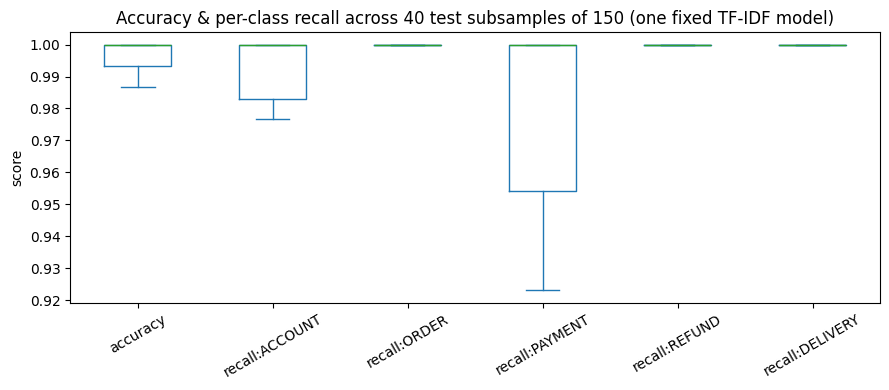

In [4]:
n_repeats = 40
n_test    = 150   # size of each test subsample drawn from the fixed pool
rows = []
for seed in range(n_repeats):
    t = evaluate_resample(prep['y_true'], prep['tfidf_pred'], labels, n=n_test, seed=seed)
    row = {'accuracy': t['accuracy']}
    for c in labels:
        row[f'recall:{c}'] = t['per_class'][c]['recall']
    rows.append(row)
df_b = pd.DataFrame(rows)
print(df_b.describe().loc[['mean','std','min','max']].round(3).T)

fig, ax = plt.subplots(figsize=(9, 4))
df_b.plot(kind='box', ax=ax, rot=30)
ax.set_title(f'Accuracy & per-class recall across {n_repeats} test subsamples of {n_test} (one fixed TF-IDF model)')
ax.set_ylabel('score')
plt.tight_layout(); plt.show()

## Demo C — Class imbalance and a trivial baseline

Now draw **class-imbalanced** test subsamples: as `skew` rises, the majority class dominates
the draw. Compare the trained TF-IDF model against a do-nothing **MajorityBaseline** that always
predicts the single most common class.

As skew grows, the baseline's **accuracy** climbs — it's just riding the dominant class — but its
**macro-recall** (recall averaged over all five classes, every class equal) stays pinned near
1/5. Aggregate accuracy flatters the trivial model; macro-recall exposes it. We formalize this
in **Lesson 4** — here, just feel the gap.

(We reuse Demo A's fixed predictions; only the *test sampling* changes.)

majority class = ACCOUNT

   skew  maj_share  baseline_acc  baseline_macroR  tfidf_acc  tfidf_macroR
0   0.0      0.347         0.347              0.2      0.997         0.998
1   0.3      0.450         0.450              0.2      0.997         0.999
2   0.6      0.560         0.560              0.2      0.997         0.999
3   0.9      0.847         0.847              0.2      0.997         0.999


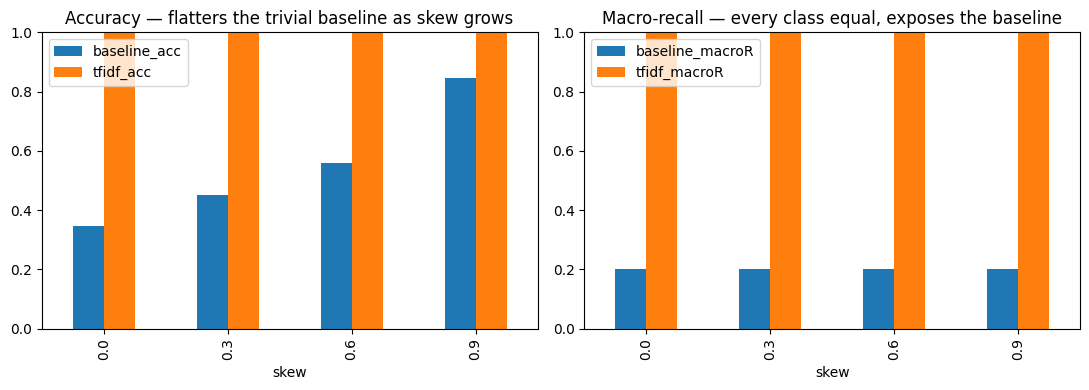

In [5]:
freq     = Counter(label_of(l) for l in bitext['labels'])
majority = freq.most_common(1)[0][0]
print(f'majority class = {majority}\n')

rows = []
for skew in [0.0, 0.3, 0.6, 0.9]:
    idx = skewed_indices(prep['y_true'], n=300, majority=majority, skew=skew, seed=0)
    yt        = [prep['y_true'][i]    for i in idx]
    tfidf_sub = [prep['tfidf_pred'][i] for i in idx]
    maj_pred  = [[majority] for _ in idx]
    m_base  = evaluate(yt, maj_pred,  labels)
    m_tfidf = evaluate(yt, tfidf_sub, labels)
    rows.append({
        'skew': skew,
        'maj_share':       np.mean([label_of(x) == majority for x in yt]),
        'baseline_acc':    m_base['accuracy'],
        'baseline_macroR': m_base['macro_recall'],
        'tfidf_acc':       m_tfidf['accuracy'],
        'tfidf_macroR':    m_tfidf['macro_recall'],
    })
df_c = pd.DataFrame(rows)
print(df_c.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df_c.set_index('skew')[['baseline_acc','tfidf_acc']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Accuracy — flatters the trivial baseline as skew grows'); axes[0].set_ylim(0, 1)
df_c.set_index('skew')[['baseline_macroR','tfidf_macroR']].plot(kind='bar', ax=axes[1])
axes[1].set_title('Macro-recall — every class equal, exposes the baseline'); axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

## Demo D — The jaggedness: *where* the classifier is right and wrong

Demos A–C treated accuracy as a number. Now we **look at the test set itself**. Each ticket is
embedded, projected to 2D, and colored by whether the trained classifier got it right. The
point: right and wrong patches **interlock — there is no clean boundary**, and that jaggedness
is a property of the model, not something more data smooths away. So a fresh random draw lands
on a different mix of right/wrong dots and reports a different score — *that's* the L1 sampling
noise, made visible.

We lay the same tickets out in two genuinely different feature spaces: the **lexical TF-IDF**
space the model actually decides in, and a **semantic embedding** space (meaning → close).

In [6]:
# Demo D: build the jaggedness picture on bitext (multi-class, honestly imperfect)
from lab import make_split
from sklearn.feature_extraction.text import TfidfVectorizer

bx = load_bitext(n=2000)
train_bx, test_bx = make_split(bx, train_frac=0.7, seed=0)

# Weakened TF-IDF model — mirrors build_predictions.py for bitext, so accuracy (~75-85%)
# carries real uncertainty instead of being trivially perfect.
clf = TfidfLogRegClassifier(max_features=50, ngram_range=(1, 1), min_df=1, C=0.6)
clf.fit(train_bx['text'].tolist(), train_bx['labels'].tolist())
pred    = [label_of(p) for p in clf.predict(test_bx['text'].tolist())]
truth   = [label_of(l) for l in test_bx['labels'].tolist()]
correct = np.array([p == t for p, t in zip(pred, truth)])
texts   = test_bx['text'].tolist()
print(f'bitext test pool: {len(correct)} cases, overall accuracy {correct.mean():.3f}')

# Lexical feature space: a TF-IDF over the test texts ('same words -> close')
lex_X = TfidfVectorizer(min_df=2).fit_transform(texts)

# Semantic space: a real sentence-transformer if available, else LSA (SVD of TF-IDF).
try:
    from sentence_transformers import SentenceTransformer
    sem_X = SentenceTransformer('all-MiniLM-L6-v2').encode(texts, show_progress_bar=False)
    sem_name = 'MiniLM sentence embeddings'
except Exception:
    from sklearn.decomposition import TruncatedSVD
    sem_X = TruncatedSVD(n_components=64, random_state=0).fit_transform(lex_X)
    sem_name = 'LSA (TF-IDF -> SVD-64)'
print('semantic space:', sem_name)

def project_2d(X, seed=0):
    """X (sparse or dense) -> (n, 2). UMAP if installed, else t-SNE, else PCA."""
    Xd = X.toarray() if hasattr(X, 'toarray') else np.asarray(X)
    try:
        import umap
        return umap.UMAP(n_components=2, random_state=seed).fit_transform(Xd), 'UMAP'
    except Exception:
        from sklearn.manifold import TSNE
        return TSNE(n_components=2, init='pca', random_state=seed, perplexity=30).fit_transform(Xd), 't-SNE'

lex_2d, proj = project_2d(lex_X)
sem_2d, _    = project_2d(sem_X)
print('2D projection:', proj)

bitext test pool: 600 cases, overall accuracy 0.910


semantic space: LSA (TF-IDF -> SVD-64)


2D projection: t-SNE


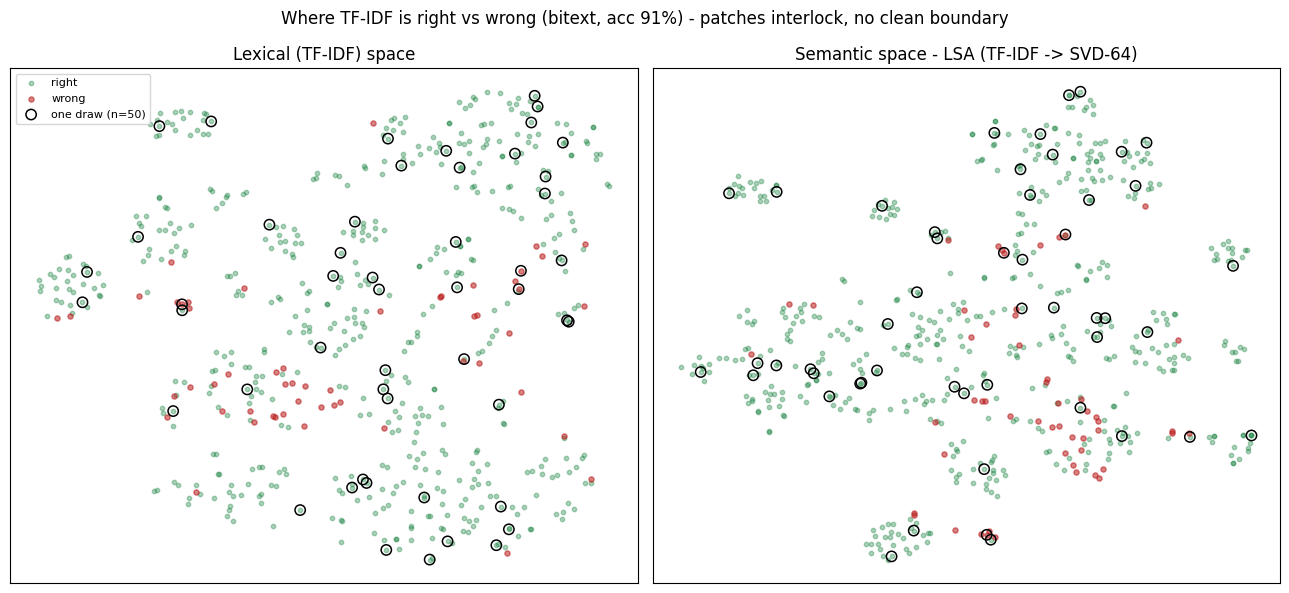

In [7]:
# Plot both feature spaces, colored by right/wrong, with ONE random test draw highlighted.
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
draw = np.random.RandomState(1).choice(len(correct), 50, replace=False)
for ax, coords, title in [(axes[0], lex_2d, 'Lexical (TF-IDF) space'),
                          (axes[1], sem_2d, f'Semantic space - {sem_name}')]:
    ax.scatter(coords[correct, 0],  coords[correct, 1],  s=10, c='#15803d', alpha=.35, label='right')
    ax.scatter(coords[~correct, 0], coords[~correct, 1], s=14, c='#b91c1c', alpha=.55, label='wrong')
    ax.scatter(coords[draw, 0], coords[draw, 1], s=55, facecolors='none',
               edgecolors='k', linewidths=1.1, label='one draw (n=50)')
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
axes[0].legend(loc='best', fontsize=8)
plt.suptitle(f'Where TF-IDF is right vs wrong (bitext, acc {correct.mean():.0%}) - patches interlock, no clean boundary')
plt.tight_layout(); plt.show()

In [8]:
# Tie it back to sampling noise: same fixed model, six different draws of 50 -> six scores.
for s in range(6):
    d = np.random.RandomState(s).choice(len(correct), 50, replace=False)
    print(f'draw {s}: accuracy on 50 cases = {correct[d].mean():.0%}')
print(f'\nfull-pool accuracy = {correct.mean():.0%}  - every draw above is one noisy estimate of it')

draw 0: accuracy on 50 cases = 92%
draw 1: accuracy on 50 cases = 94%
draw 2: accuracy on 50 cases = 90%
draw 3: accuracy on 50 cases = 92%
draw 4: accuracy on 50 cases = 90%
draw 5: accuracy on 50 cases = 94%

full-pool accuracy = 91%  - every draw above is one noisy estimate of it


## The L1 takeaway

Four things you should have *felt* in this lab:

1. **One headline number hides a per-class story.** Demo A's accuracy is a summary — the
   per-class recall table shows where the model actually fails.
2. **A single accuracy is one draw.** Demo B's box plot shows how much your headline number can
   move just by drawing a different test sample — *the model never changed*, only the test cases
   did. Rare-class recall wobbles much more than overall accuracy.
3. **Aggregate accuracy can flatter trivial models.** Demo C shows a "predict-the-majority-class"
   baseline catching up on accuracy as the data skews — and macro-recall is the only honest signal.
4. **The wobble has a shape.** Demo D plots *where* the model is right and wrong: right and wrong
   interlock with no clean boundary, so each draw lands on a different mix and reports a different
   score. The jaggedness is the mechanism behind the wobble.

All four are L1's sampling-noise dimension in disguise. The course returns to these ideas:
Demo A -> L2/L3 (metrics & what they measure), Demo B -> L4 (sampling noise -> multiple
comparisons), Demo C -> L4 (imbalance), Demo D -> the geometry behind it all.